In [1]:
import torch

print("=" * 80)
print("GPU CHECK")
print("=" * 80)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("GPU count:", torch.cuda.device_count())
else:
    print("WARNING: CUDA GPU not available")

print("=" * 80)

GPU CHECK
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
GPU count: 2


In [2]:
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms
from torchvision.models import vgg19, VGG19_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    log_loss,
    cohen_kappa_score,
    matthews_corrcoef,
    brier_score_loss
)

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seed:", SEED)

Seed: 42


In [4]:
# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 50

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 5e-4

NUM_CLASSES = 5

NUM_WORKERS = 2

EARLY_STOPPING_PATIENCE = 100
LR_PATIENCE = 3
LR_FACTOR = 0.5
MIN_LR = 1e-7

MODEL_NAME = "VGG19"

CLASS_NAMES = ["0_No_DR", "1_Mild", "2_Moderate", "3_Severe", "4_Proliferative_DR"]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("VGG19 — APTOS CONFIGURATION")
print("=" * 80)

print("Model:", MODEL_NAME)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Weight decay:", WEIGHT_DECAY)
print("Classes:", NUM_CLASSES)
print("Device:", DEVICE)
print("=" * 80)

VGG19 — APTOS CONFIGURATION
Model: VGG19
Image size: 224
Batch size: 16
Epochs: 50
Learning rate: 0.0001
Weight decay: 0.0005
Classes: 5
Device: cuda


In [5]:
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

print("Available Kaggle inputs:")

for p in KAGGLE_INPUT.iterdir():
    print(" -", p)

Available Kaggle inputs:
 - /kaggle/input/datasets


In [6]:
def find_dataset_root(base_dir="/kaggle/input"):
    base_dir = Path(base_dir)

    candidates = []

    for path in base_dir.rglob("train"):
        if not path.is_dir():
            continue

        parent = path.parent

        if (
            (parent / "val").is_dir()
            and (parent / "test").is_dir()
        ):
            candidates.append(parent)

    if not candidates:
        raise FileNotFoundError(
            "Could not automatically locate APTOS train/val/test folders."
        )

    return candidates[0]


DATASET_ROOT = find_dataset_root()

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("=" * 80)
print("DATASET LOCATION")
print("=" * 80)

print("Dataset root:", DATASET_ROOT)
print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)

DATASET LOCATION
Dataset root: /kaggle/input/datasets/samjohnstonc/dr-classification/aptos
Train: /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train
Val: /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val
Test: /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/test


In [7]:
print("=" * 80)
print("DATASET STRUCTURE")
print("=" * 80)

for split_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    print("\n", split_dir)

    for class_name in CLASS_NAMES:

        class_dir = split_dir / class_name

        if class_dir.exists():
            count = len(list(class_dir.glob("*")))
            print(f"  {class_name:20s}: {count}")
        else:
            print(f"  {class_name:20s}: MISSING")

DATASET STRUCTURE

 /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/train
  0_No_DR             : 1436
  1_Mild              : 270
  2_Moderate          : 738
  3_Severe            : 141
  4_Proliferative_DR  : 217

 /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/val
  0_No_DR             : 180
  1_Mild              : 34
  2_Moderate          : 92
  3_Severe            : 18
  4_Proliferative_DR  : 27

 /kaggle/input/datasets/samjohnstonc/dr-classification/aptos/test
  0_No_DR             : 180
  1_Mild              : 34
  2_Moderate          : 92
  3_Severe            : 18
  4_Proliferative_DR  : 27


In [8]:
def count_images(split_dir):

    counts = {}

    for class_name in CLASS_NAMES:

        class_dir = split_dir / class_name

        counts[class_name] = len(
            [
                f for f in class_dir.iterdir()
                if f.is_file()
            ]
        )

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN:", train_counts)
print("VAL  :", val_counts)
print("TEST :", test_counts)

TRAIN: {'0_No_DR': 1436, '1_Mild': 270, '2_Moderate': 738, '3_Severe': 141, '4_Proliferative_DR': 217}
VAL  : {'0_No_DR': 180, '1_Mild': 34, '2_Moderate': 92, '3_Severe': 18, '4_Proliferative_DR': 27}
TEST : {'0_No_DR': 180, '1_Mild': 34, '2_Moderate': 92, '3_Severe': 18, '4_Proliferative_DR': 27}


In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("ImageNet mean:", IMAGENET_MEAN)
print("ImageNet std :", IMAGENET_STD)

ImageNet mean: [0.485, 0.456, 0.406]
ImageNet std : [0.229, 0.224, 0.225]


In [10]:
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomRotation(
        degrees=40
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.20, 0.20),
        shear=0.20,
        scale=(0.80, 1.20)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [11]:
eval_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

print("Transforms created.")

Transforms created.


In [12]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("=" * 80)
print("DATASETS")
print("=" * 80)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

DATASETS
Train: 2802
Val  : 351
Test : 351

Class mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}


In [13]:
assert train_dataset.class_to_idx == {
    "0_No_DR": 0,
    "1_Mild": 1,
    "2_Moderate": 2,
    "3_Severe": 3,
    "4_Proliferative_DR": 4
}, "Class mapping differs from alphabetical ImageFolder ordering."

print("ImageFolder alphabetical mapping:")
print(train_dataset.class_to_idx)

print("\nIMPORTANT:")
print("Internal ImageFolder indices are alphabetical.")

ImageFolder alphabetical mapping:
{'0_No_DR': 0, '1_Mild': 1, '2_Moderate': 2, '3_Severe': 3, '4_Proliferative_DR': 4}

IMPORTANT:
Internal ImageFolder indices are alphabetical.


In [14]:
targets = np.array(train_dataset.targets)

unique, counts = np.unique(
    targets,
    return_counts=True
)

print("=" * 80)
print("TRAINING CLASS COUNTS")
print("=" * 80)

for idx, count in zip(unique, counts):
    print(
        f"{train_dataset.classes[idx]:20s}: {count}"
    )

TRAINING CLASS COUNTS
0_No_DR             : 1436
1_Mild              : 270
2_Moderate          : 738
3_Severe            : 141
4_Proliferative_DR  : 217


In [15]:
class_counts = np.bincount(
    train_dataset.targets
)

class_weights = 1.0 / class_counts

sample_weights = np.array([
    class_weights[label]
    for label in train_dataset.targets
])

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [1436  270  738  141  217]
Class weights: [0.00069638 0.0037037  0.00135501 0.0070922  0.00460829]


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("DataLoaders ready.")

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders ready.
Train batches: 176
Val batches: 22
Test batches: 22


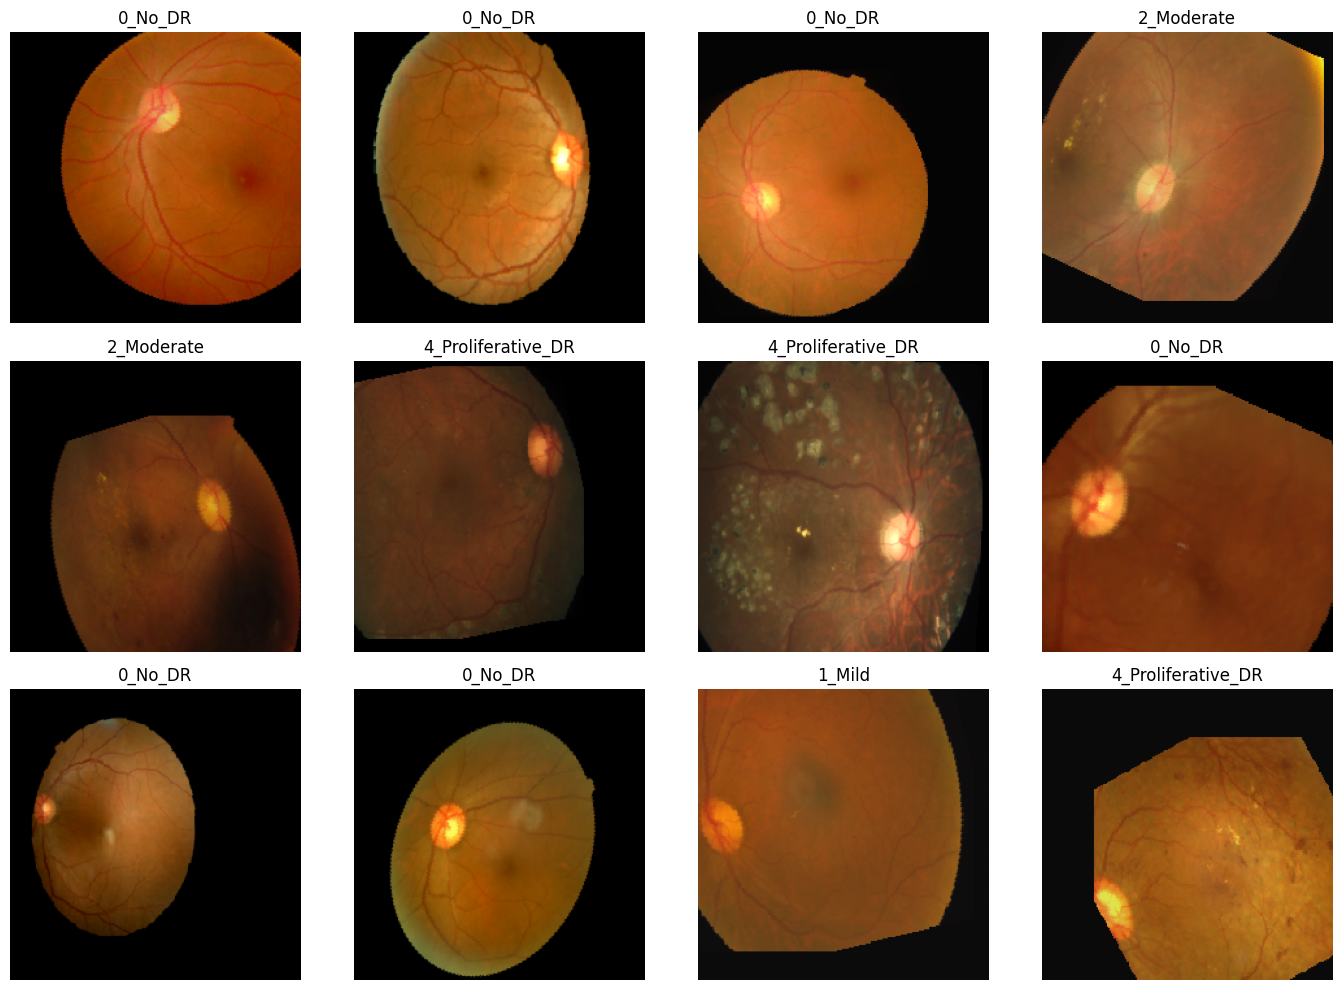

In [17]:
def denormalize(img):

    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    img = img.cpu() * std + mean

    return torch.clamp(img, 0, 1)


images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 10))

for i in range(min(12, len(images))):

    plt.subplot(3, 4, i + 1)

    img = denormalize(images[i])
    img = img.permute(1, 2, 0)

    plt.imshow(img)

    label_idx = labels[i].item()

    plt.title(
        train_dataset.classes[label_idx]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
print("=" * 80)
print("BUILDING VGG19")
print("=" * 80)

weights = VGG19_Weights.IMAGENET1K_V1

model = vgg19(
    weights=weights
)

# Replace ImageNet classifier
in_features = model.classifier[6].in_features

model.classifier[6] = nn.Linear(
    in_features,
    NUM_CLASSES
)

model = model.to(DEVICE)

print(model.classifier)

BUILDING VGG19
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 215MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=5, bias=True)
)


In [19]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("MODEL PARAMETERS")
print("=" * 80)

print(
    f"Total parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)

MODEL PARAMETERS
Total parameters     : 139,590,725
Trainable parameters : 139,590,725


In [20]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [21]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(optimizer)

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0005
)


In [22]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR
)

print("Scheduler:", scheduler)

Scheduler: <torch.optim.lr_scheduler.ReduceLROnPlateau object at 0x7bf8f8096660>


In [23]:
def calculate_metrics(
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall_weighted = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )

    kappa = cohen_kappa_score(
        y_true,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_true,
        y_pred
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "balanced_accuracy": balanced_acc,
        "kappa": kappa,
        "mcc": mcc
    }

In [24]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        preds = outputs.argmax(
            dim=1
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    metrics = calculate_metrics(
        all_labels,
        all_preds
    )

    return epoch_loss, metrics

In [25]:
@torch.no_grad()
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_probs = []
    all_preds = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = probabilities.argmax(
            dim=1
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        all_probs.append(
            probabilities.cpu().numpy()
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    epoch_loss = (
        running_loss /
        len(loader.dataset)
    )

    all_probs = np.concatenate(
        all_probs,
        axis=0
    )

    all_labels = np.array(
        all_labels
    )

    all_preds = np.array(
        all_preds
    )

    metrics = calculate_metrics(
        all_labels,
        all_preds
    )

    return (
        epoch_loss,
        metrics,
        all_labels,
        all_preds,
        all_probs
    )

In [26]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_accuracy": [],
    "val_accuracy": [],

    "train_precision_macro": [],
    "val_precision_macro": [],

    "train_recall_macro": [],
    "val_recall_macro": [],

    "train_f1_macro": [],
    "val_f1_macro": [],

    "learning_rate": []
}

print("History initialized.")

History initialized.


In [27]:
OUTPUT_DIR = Path("/kaggle/working/vgg19_aptos_results")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_PATH = (
    OUTPUT_DIR /
    "best_vgg19_aptos.pth"
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
/kaggle/working/vgg19_aptos_results


In [28]:
print("=" * 90)
print("STARTING VGG19 TRAINING")
print("=" * 90)

best_val_f1 = -float("inf")
epochs_without_improvement = 0

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    epoch_start = time.time()

    # -------------------------
    # TRAIN
    # -------------------------

    train_loss, train_metrics = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # -------------------------
    # VALIDATION
    # -------------------------

    (
        val_loss,
        val_metrics,
        _,
        _,
        _
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # -------------------------
    # SCHEDULER
    # -------------------------

    scheduler.step(
        val_metrics["f1_macro"]
    )

    current_lr = optimizer.param_groups[0]["lr"]

    # -------------------------
    # SAVE HISTORY
    # -------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_metrics["accuracy"]
    )

    history["val_accuracy"].append(
        val_metrics["accuracy"]
    )

    history["train_precision_macro"].append(
        train_metrics["precision_macro"]
    )

    history["val_precision_macro"].append(
        val_metrics["precision_macro"]
    )

    history["train_recall_macro"].append(
        train_metrics["recall_macro"]
    )

    history["val_recall_macro"].append(
        val_metrics["recall_macro"]
    )

    history["train_f1_macro"].append(
        train_metrics["f1_macro"]
    )

    history["val_f1_macro"].append(
        val_metrics["f1_macro"]
    )

    history["learning_rate"].append(
        current_lr
    )

    # -------------------------
    # CHECKPOINT
    # -------------------------

    if val_metrics["f1_macro"] > best_val_f1:

        best_val_f1 = val_metrics["f1_macro"]

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "best_val_f1": best_val_f1,
                "class_names": train_dataset.classes,
                "config": {
                    "image_size": IMAGE_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED
                }
            },
            CHECKPOINT_PATH
        )

        checkpoint_status = "SAVED"

    else:

        epochs_without_improvement += 1

        checkpoint_status = ""

    elapsed = time.time() - epoch_start

    # -------------------------
    # PRINT
    # -------------------------

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"| "
        f"Train Loss: {train_loss:.4f} "
        f"| "
        f"Val Loss: {val_loss:.4f} "
        f"| "
        f"Train Acc: {train_metrics['accuracy']:.4f} "
        f"| "
        f"Val Acc: {val_metrics['accuracy']:.4f} "
        f"| "
        f"Val Macro-F1: {val_metrics['f1_macro']:.4f} "
        f"| "
        f"LR: {current_lr:.2e} "
        f"| "
        f"{elapsed:.1f}s "
        f"{checkpoint_status}"
    )

    # -------------------------
    # EARLY STOPPING
    # -------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            f"\nEarly stopping triggered at epoch {epoch}."
        )

        break

total_training_time = (
    time.time() - start_time
)

print("\nTraining completed.")

print(
    f"Total training time: "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"Best validation Macro-F1: "
    f"{best_val_f1:.4f}"
)

STARTING VGG19 TRAINING
Epoch [01/50] | Train Loss: 1.2399 | Val Loss: 0.6868 | Train Acc: 0.4425 | Val Acc: 0.6724 | Val Macro-F1: 0.4770 | LR: 1.00e-04 | 259.5s SAVED
Epoch [02/50] | Train Loss: 0.9961 | Val Loss: 0.5500 | Train Acc: 0.5692 | Val Acc: 0.7835 | Val Macro-F1: 0.5672 | LR: 1.00e-04 | 256.1s SAVED
Epoch [03/50] | Train Loss: 0.9187 | Val Loss: 0.6203 | Train Acc: 0.6081 | Val Acc: 0.7236 | Val Macro-F1: 0.5483 | LR: 1.00e-04 | 256.8s 
Epoch [04/50] | Train Loss: 0.8520 | Val Loss: 0.5317 | Train Acc: 0.6367 | Val Acc: 0.7407 | Val Macro-F1: 0.5696 | LR: 1.00e-04 | 253.5s SAVED
Epoch [05/50] | Train Loss: 0.8294 | Val Loss: 0.7002 | Train Acc: 0.6502 | Val Acc: 0.7407 | Val Macro-F1: 0.4861 | LR: 1.00e-04 | 250.5s 
Epoch [06/50] | Train Loss: 0.7961 | Val Loss: 0.5206 | Train Acc: 0.6681 | Val Acc: 0.7635 | Val Macro-F1: 0.5976 | LR: 1.00e-04 | 254.3s SAVED
Epoch [07/50] | Train Loss: 0.7290 | Val Loss: 0.5352 | Train Acc: 0.7013 | Val Acc: 0.7664 | Val Macro-F1: 0.5922 |

In [29]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    OUTPUT_DIR / "training_history.csv",
    index=False
)

print(history_df.tail())

    train_loss  val_loss  train_accuracy  val_accuracy  train_precision_macro  \
45    0.074373  0.728390        0.976802      0.831909               0.977111   
46    0.069449  0.752625        0.976089      0.826211               0.976251   
47    0.077451  0.728764        0.975732      0.826211               0.975774   
48    0.064584  0.741551        0.978587      0.834758               0.978833   
49    0.070696  0.746162        0.973947      0.829060               0.973858   

    val_precision_macro  train_recall_macro  val_recall_macro  train_f1_macro  \
45             0.685886            0.977072          0.657314        0.977076   
46             0.677140            0.976383          0.645091        0.976291   
47             0.678493            0.975780          0.654029        0.975753   
48             0.692267            0.978889          0.667967        0.978855   
49             0.680373            0.973929          0.650974        0.973877   

    val_f1_macro  learning

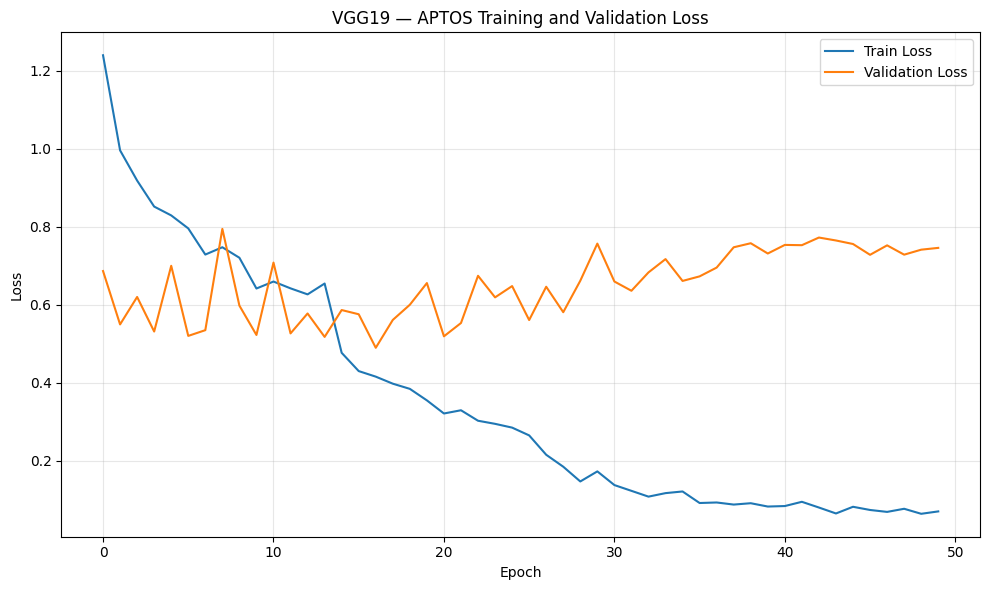

In [30]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "VGG19 — APTOS Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

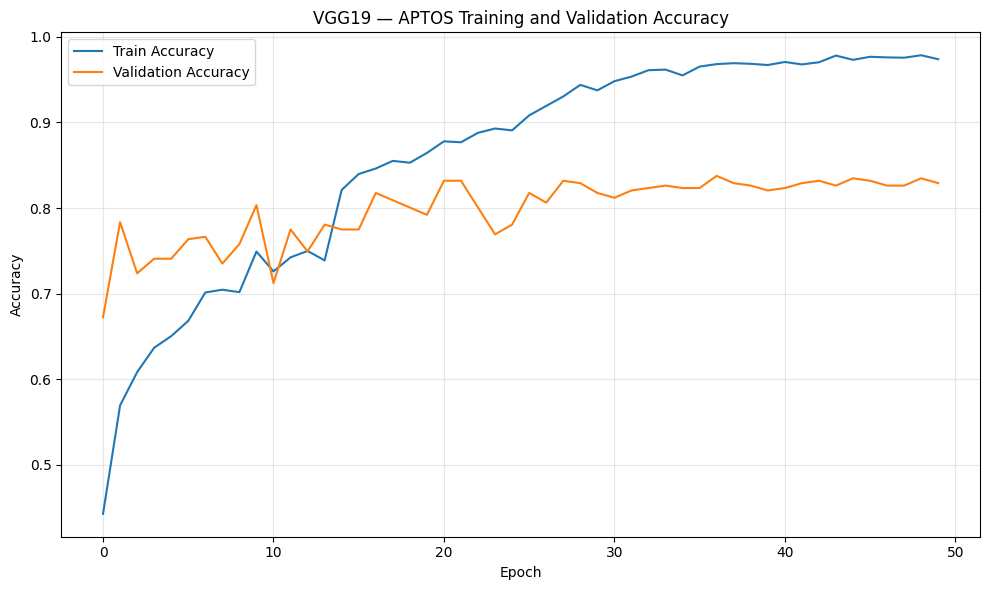

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "VGG19 — APTOS Training and Validation Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

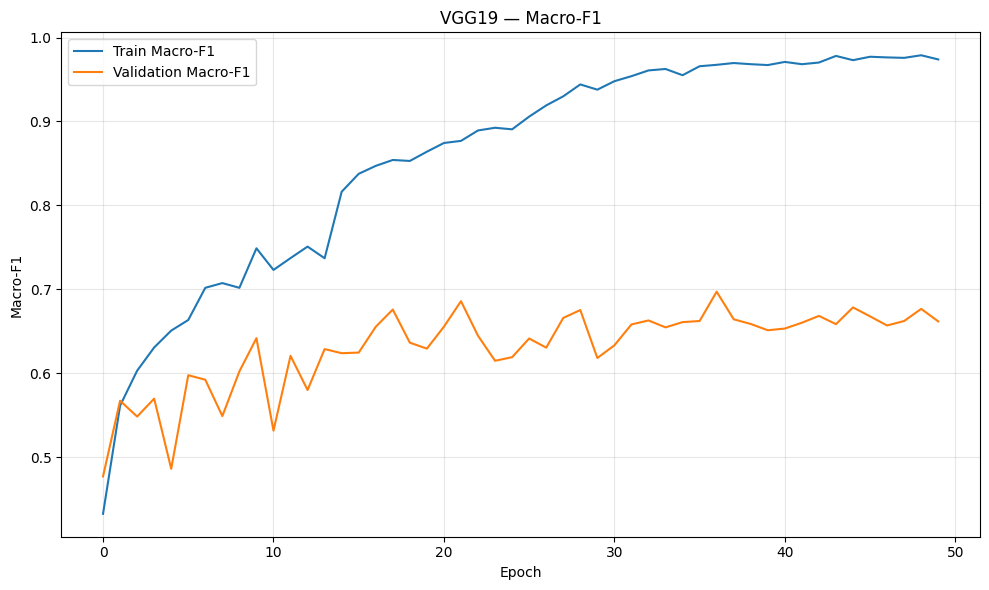

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["train_f1_macro"],
    label="Train Macro-F1"
)

plt.plot(
    history["val_f1_macro"],
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "VGG19 — Macro-F1"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "macro_f1_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

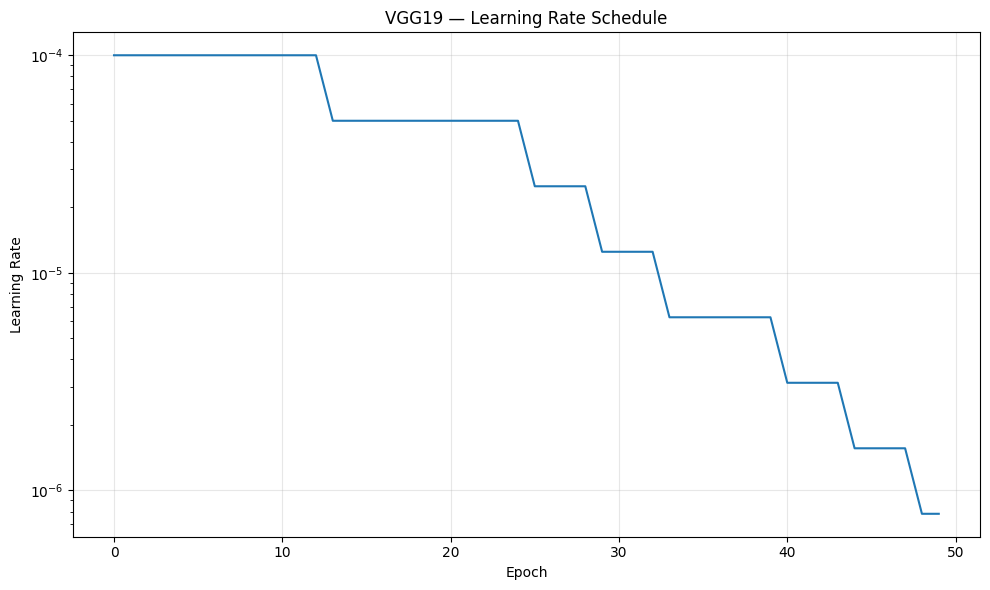

In [33]:
plt.figure(figsize=(10, 6))

plt.plot(
    history["learning_rate"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "VGG19 — Learning Rate Schedule"
)

plt.yscale("log")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "learning_rate_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [34]:
print("=" * 80)
print("LOADING BEST CHECKPOINT")
print("=" * 80)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Macro-F1:",
    checkpoint["best_val_f1"]
)

LOADING BEST CHECKPOINT
Best epoch: 37
Best validation Macro-F1: 0.6971109885555277


In [35]:
(
    test_loss,
    test_metrics,
    y_true,
    y_pred,
    y_probs
) = evaluate_model(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("=" * 80)
print("VGG19 — APTOS TEST RESULTS")
print("=" * 80)

print(
    f"Test Loss          : {test_loss:.4f}"
)

print(
    f"Accuracy            : {test_metrics['accuracy']:.4f}"
)

print(
    f"Macro Precision     : {test_metrics['precision_macro']:.4f}"
)

print(
    f"Macro Recall        : {test_metrics['recall_macro']:.4f}"
)

print(
    f"Macro F1            : {test_metrics['f1_macro']:.4f}"
)

print(
    f"Weighted Precision  : {test_metrics['precision_weighted']:.4f}"
)

print(
    f"Weighted Recall     : {test_metrics['recall_weighted']:.4f}"
)

print(
    f"Weighted F1         : {test_metrics['f1_weighted']:.4f}"
)

print(
    f"Balanced Accuracy   : {test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"Cohen Kappa         : {test_metrics['kappa']:.4f}"
)

print(
    f"MCC                 : {test_metrics['mcc']:.4f}"
)

VGG19 — APTOS TEST RESULTS
Test Loss          : 0.7660
Accuracy            : 0.8405
Macro Precision     : 0.7211
Macro Recall        : 0.6442
Macro F1            : 0.6698
Weighted Precision  : 0.8385
Weighted Recall     : 0.8405
Weighted F1         : 0.8326
Balanced Accuracy   : 0.6442
Cohen Kappa         : 0.7504
MCC                 : 0.7543


In [36]:
report = classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    digits=4,
    zero_division=0
)

print(report)

with open(
    OUTPUT_DIR / "classification_report.txt",
    "w"
) as f:

    f.write(report)

                    precision    recall  f1-score   support

           0_No_DR     0.9944    0.9889    0.9916       180
            1_Mild     0.6538    0.5000    0.5667        34
        2_Moderate     0.6983    0.8804    0.7788        92
          3_Severe     0.5714    0.4444    0.5000        18
4_Proliferative_DR     0.6875    0.4074    0.5116        27

          accuracy                         0.8405       351
         macro avg     0.7211    0.6442    0.6698       351
      weighted avg     0.8385    0.8405    0.8326       351



In [37]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=train_dataset.classes,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(
    report_dict
).transpose()

display(report_df)

report_df.to_csv(
    OUTPUT_DIR / "classification_report.csv"
)

,precision,recall,f1-score,support
0_No_DR,0.994413,0.988889,0.991643,180.000000
1_Mild,0.653846,0.500000,0.566667,34.000000
2_Moderate,0.698276,0.880435,0.778846,92.000000
3_Severe,0.571429,0.444444,0.500000,18.000000
4_Proliferative_DR,0.687500,0.407407,0.511628,27.000000
accuracy,0.840456,0.840456,0.840456,0.840456
macro avg,0.721093,0.644235,0.669757,351.000000
weighted avg,0.838504,0.840456,0.832565,351.000000


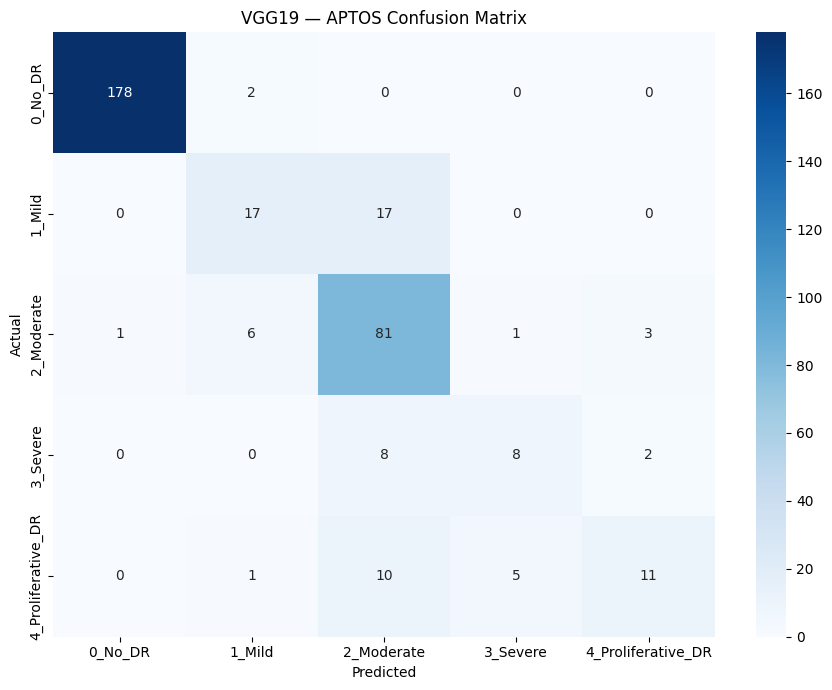

In [38]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "VGG19 — APTOS Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

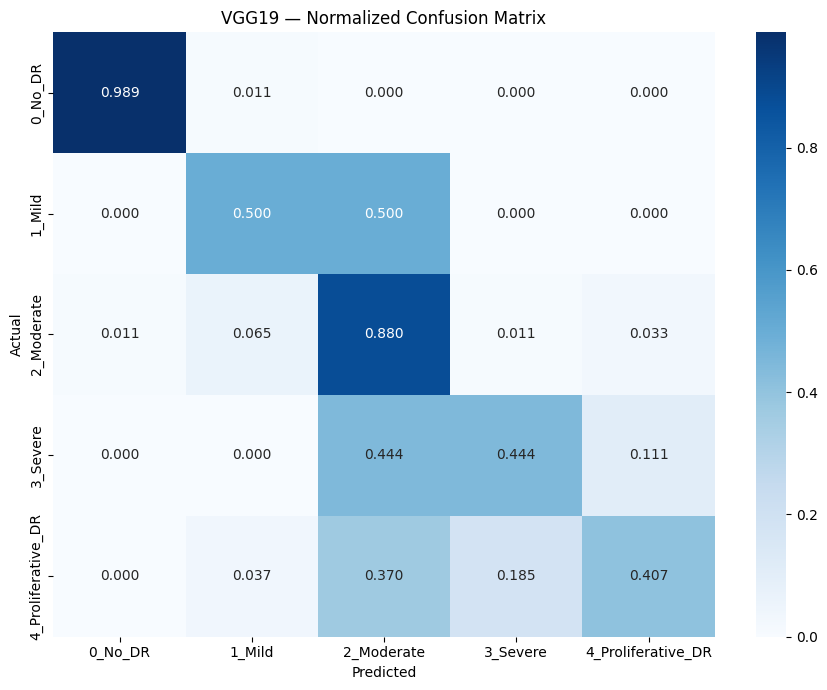

In [39]:
cm_normalized = (
    cm.astype(float) /
    cm.sum(axis=1, keepdims=True)
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "VGG19 — Normalized Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "normalized_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
specificity = []
sensitivity = []

for i in range(NUM_CLASSES):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - (
        TP + FN + FP
    )

    sens = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else 0
    )

    spec = (
        TN / (TN + FP)
        if (TN + FP) > 0
        else 0
    )

    sensitivity.append(sens)
    specificity.append(spec)

sens_spec_df = pd.DataFrame({

    "Class": train_dataset.classes,

    "Sensitivity":
        sensitivity,

    "Specificity":
        specificity

})

display(sens_spec_df)

sens_spec_df.to_csv(
    OUTPUT_DIR / "sensitivity_specificity.csv",
    index=False
)

,Class,Sensitivity,Specificity
0,0_No_DR,0.988889,0.994152
1,1_Mild,0.500000,0.971609
2,2_Moderate,0.880435,0.864865
3,3_Severe,0.444444,0.981982
4,4_Proliferative_DR,0.407407,0.984568


In [41]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

roc_auc_macro = roc_auc_score(
    y_true_bin,
    y_probs,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    y_probs,
    average="weighted",
    multi_class="ovr"
)

print(
    f"Macro ROC-AUC    : {roc_auc_macro:.4f}"
)

print(
    f"Weighted ROC-AUC : {roc_auc_weighted:.4f}"
)

Macro ROC-AUC    : 0.9494
Weighted ROC-AUC : 0.9687


In [42]:
roc_auc_per_class = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    roc_auc_per_class[class_name] = (
        roc_auc_score(
            y_true_bin[:, i],
            y_probs[:, i]
        )
    )

roc_auc_df = pd.DataFrame({
    "Class": list(
        roc_auc_per_class.keys()
    ),

    "ROC_AUC": list(
        roc_auc_per_class.values()
    )
})

display(roc_auc_df)

roc_auc_df.to_csv(
    OUTPUT_DIR / "roc_auc_per_class.csv",
    index=False
)

,Class,ROC_AUC
0,0_No_DR,0.999058
1,1_Mild,0.939135
2,2_Moderate,0.938224
3,3_Severe,0.952786
4,4_Proliferative_DR,0.917581


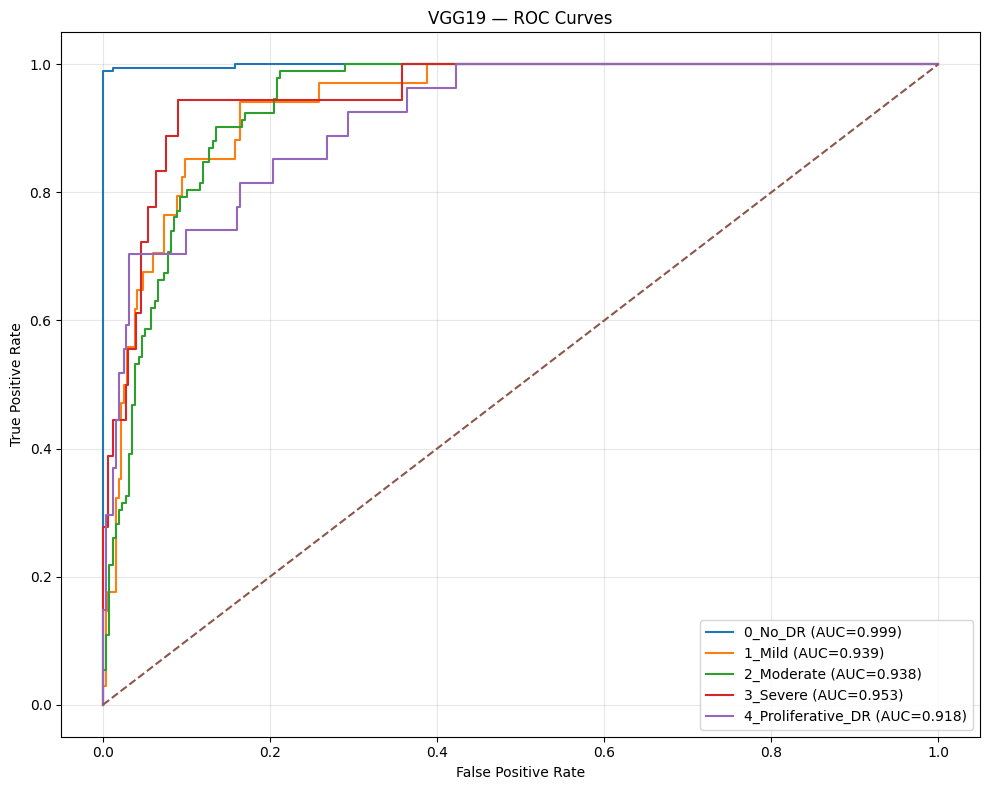

In [43]:
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(
    train_dataset.classes
):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{class_name} (AUC={roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "VGG19 — ROC Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
pr_auc_per_class = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    pr_auc = auc(
        recall,
        precision
    )

    pr_auc_per_class[class_name] = pr_auc


pr_auc_macro = np.mean(
    list(pr_auc_per_class.values())
)

print(
    f"Macro PR-AUC: {pr_auc_macro:.4f}"
)

pr_auc_df = pd.DataFrame({

    "Class":
        list(pr_auc_per_class.keys()),

    "PR_AUC":
        list(pr_auc_per_class.values())

})

display(pr_auc_df)

Macro PR-AUC: 0.7260


,Class,PR_AUC
0,0_No_DR,0.999212
1,1_Mild,0.593870
2,2_Moderate,0.799094
3,3_Severe,0.619817
4,4_Proliferative_DR,0.617780


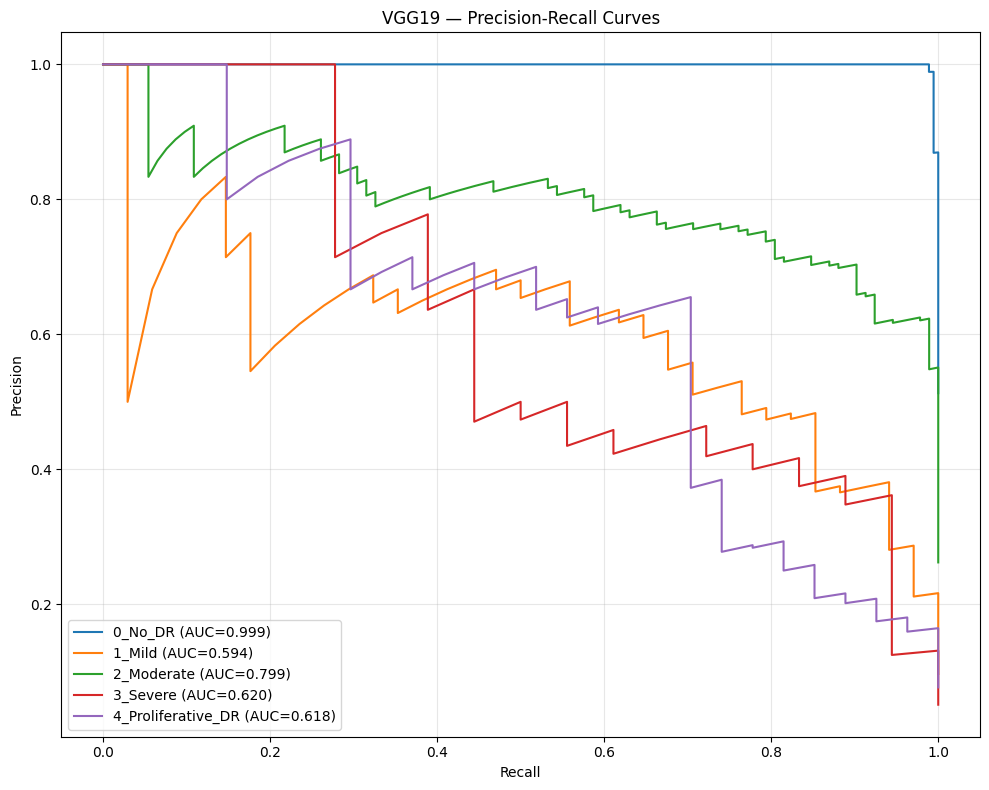

In [45]:
plt.figure(figsize=(10, 8))

for i, class_name in enumerate(
    train_dataset.classes
):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )

    pr_auc = auc(
        recall,
        precision
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "VGG19 — Precision-Recall Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
test_log_loss = log_loss(
    y_true,
    y_probs,
    labels=np.arange(NUM_CLASSES)
)

print(
    f"Test Log Loss: {test_log_loss:.6f}"
)

Test Log Loss: 0.766031


In [47]:
brier_scores = {}

for i, class_name in enumerate(
    train_dataset.classes
):

    brier_scores[class_name] = (
        brier_score_loss(
            y_true_bin[:, i],
            y_probs[:, i]
        )
    )

brier_df = pd.DataFrame({

    "Class":
        list(brier_scores.keys()),

    "Brier_Score":
        list(brier_scores.values())

})

display(brier_df)

print(
    "Mean Brier Score:",
    np.mean(
        list(brier_scores.values())
    )
)

,Class,Brier_Score
0,0_No_DR,0.007364
1,1_Mild,0.062352
2,2_Moderate,0.112068
3,3_Severe,0.036952
4,4_Proliferative_DR,0.051647


Mean Brier Score: 0.054076641847801296


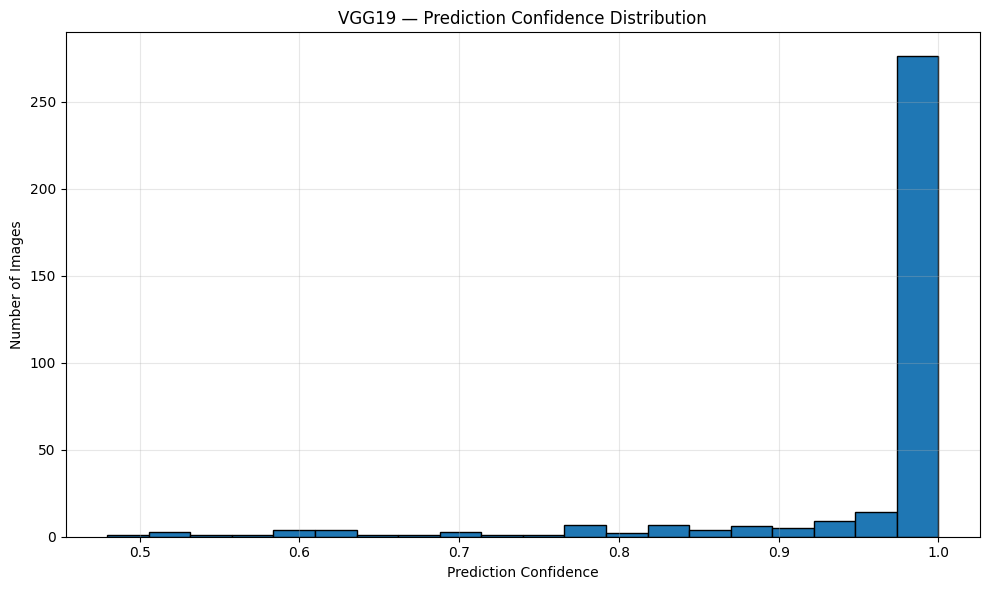

Mean confidence: 0.95926243
Median confidence: 0.9998703


In [48]:
confidence = np.max(
    y_probs,
    axis=1
)

plt.figure(figsize=(10, 6))

plt.hist(
    confidence,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Images")

plt.title(
    "VGG19 — Prediction Confidence Distribution"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Mean confidence:",
    confidence.mean()
)

print(
    "Median confidence:",
    np.median(confidence)
)

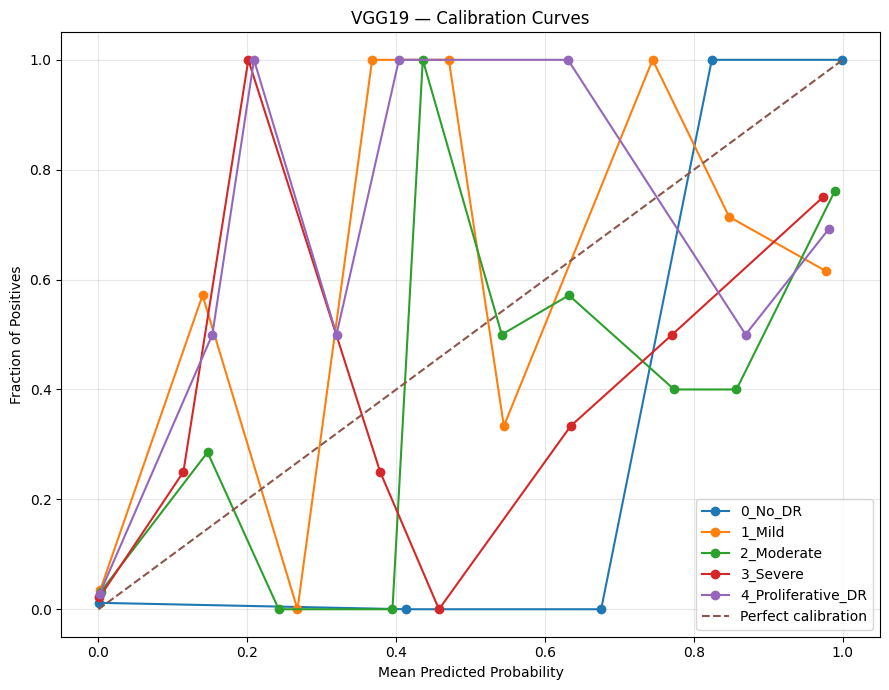

In [49]:
from sklearn.calibration import calibration_curve

plt.figure(figsize=(9, 7))

for i, class_name in enumerate(
    train_dataset.classes
):

    prob_true, prob_pred = calibration_curve(
        y_true_bin[:, i],
        y_probs[:, i],
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=class_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")

plt.title(
    "VGG19 — Calibration Curves"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "calibration_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
prediction_df = pd.DataFrame({

    "true_label": y_true,

    "predicted_label": y_pred,

    "true_class": [
        train_dataset.classes[x]
        for x in y_true
    ],

    "predicted_class": [
        train_dataset.classes[x]
        for x in y_pred
    ],

    "confidence": confidence

})

for i, class_name in enumerate(
    train_dataset.classes
):

    prediction_df[
        f"prob_{class_name}"
    ] = y_probs[:, i]

display(
    prediction_df.head()
)

prediction_df.to_csv(
    OUTPUT_DIR / "test_predictions.csv",
    index=False
)

,true_label,predicted_label,true_class,predicted_class,confidence,prob_0_No_DR,prob_1_Mild,prob_2_Moderate,prob_3_Severe,prob_4_Proliferative_DR
0,0,0,0_No_DR,0_No_DR,0.999972,0.999972,1.005023e-05,1.822164e-05,5.869585e-10,9.089089e-09
1,0,0,0_No_DR,0_No_DR,0.999994,0.999994,2.149794e-06,3.484642e-06,1.514252e-10,2.711383e-09
2,0,0,0_No_DR,0_No_DR,0.999998,0.999998,1.911277e-06,3.873499e-07,5.035972e-13,2.979708e-11
3,0,0,0_No_DR,0_No_DR,1.000000,1.000000,1.004276e-07,6.300957e-08,1.725916e-13,6.954770e-12
4,0,0,0_No_DR,0_No_DR,1.000000,1.000000,3.323293e-08,1.646081e-08,3.472944e-15,2.926630e-13


In [51]:
test_paths = [
    path
    for path, _ in test_dataset.samples
]

misclassified_indices = np.where(
    y_true != y_pred
)[0]

print(
    "Misclassified images:",
    len(misclassified_indices)
)

print(
    "Total test images:",
    len(y_true)
)

print(
    "Error rate:",
    len(misclassified_indices) /
    len(y_true)
)

Misclassified images: 56
Total test images: 351
Error rate: 0.15954415954415954


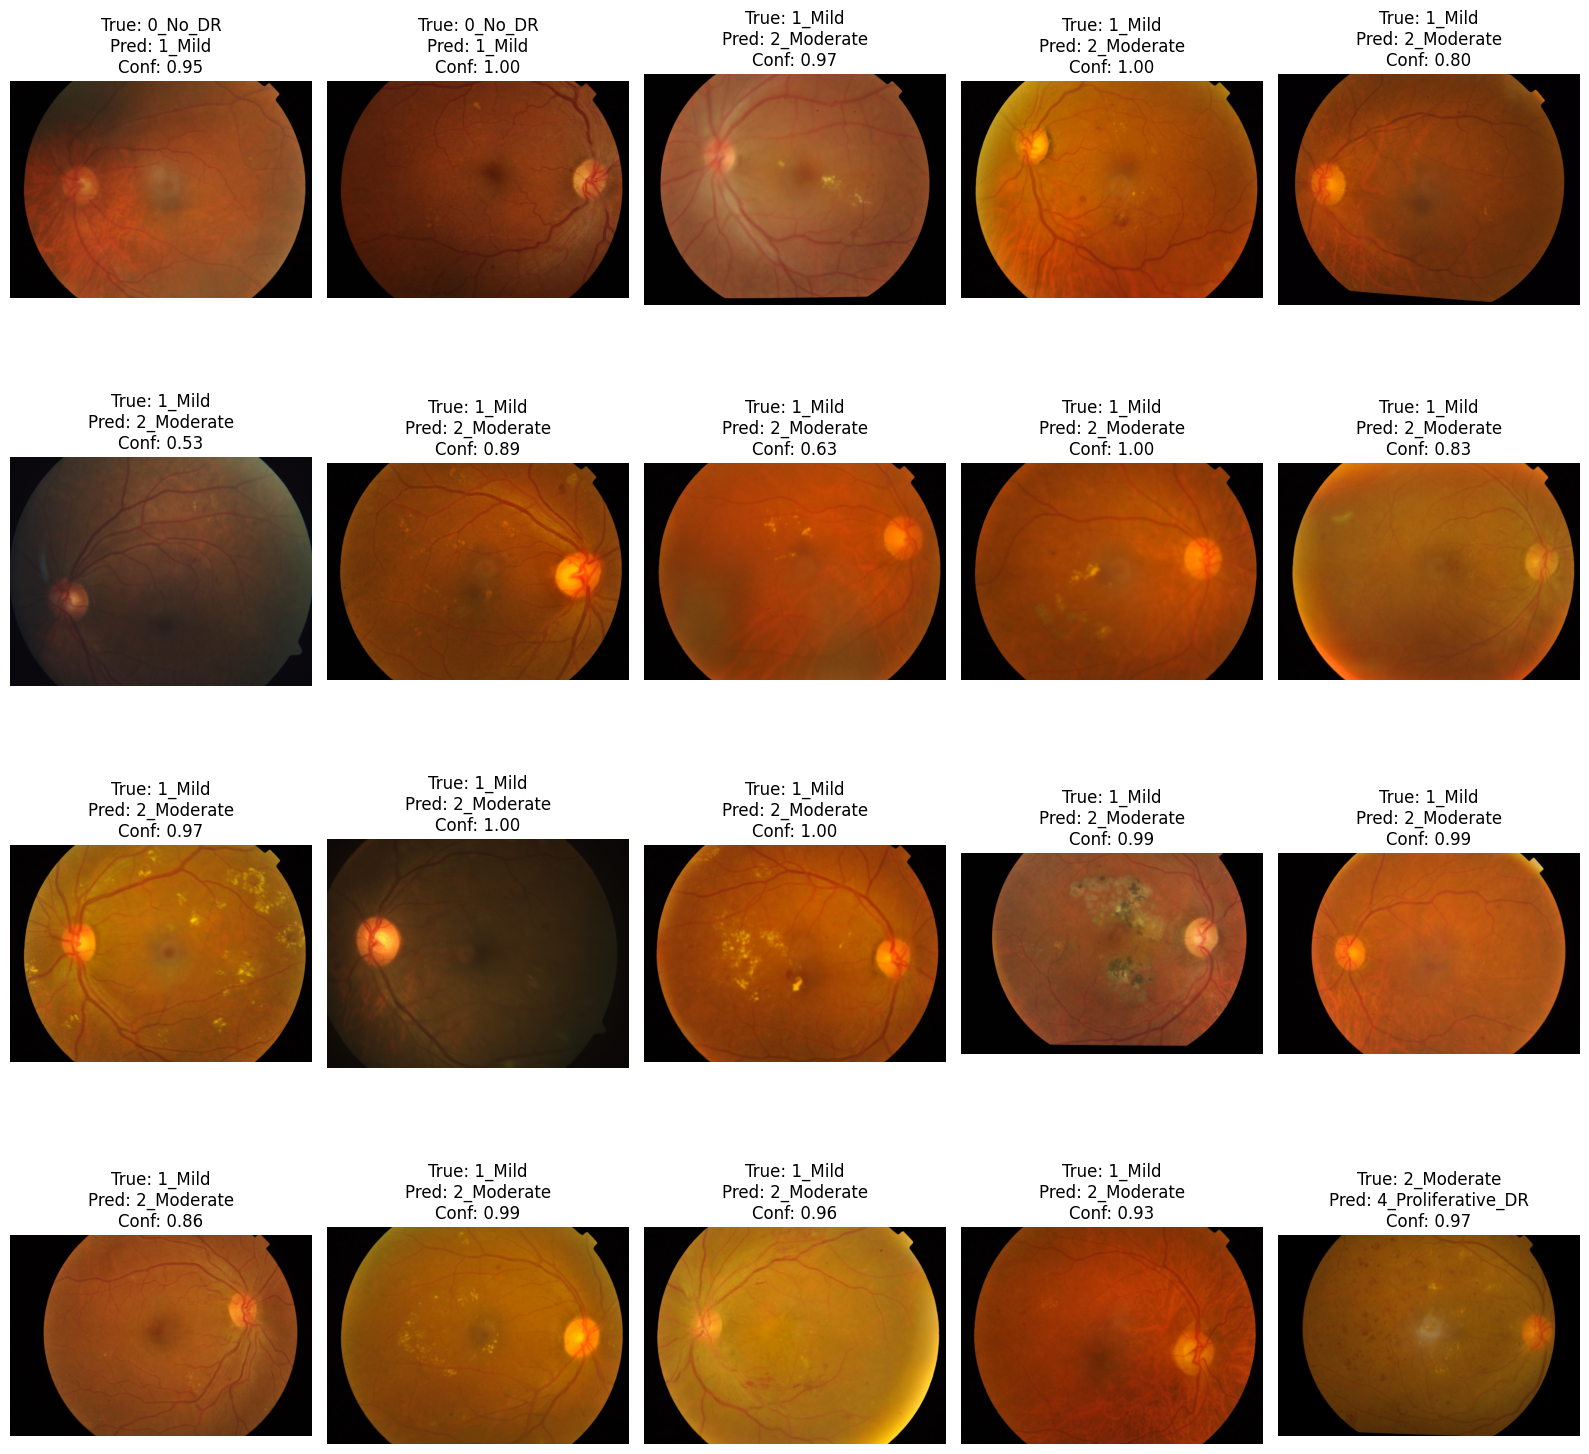

In [52]:
n_show = min(
    20,
    len(misclassified_indices)
)

plt.figure(figsize=(16, 16))

for plot_idx, sample_idx in enumerate(
    misclassified_indices[:n_show]
):

    image_path = test_paths[sample_idx]

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(4, 5, plot_idx + 1)

    plt.imshow(image)

    plt.title(
        f"True: {train_dataset.classes[y_true[sample_idx]]}\n"
        f"Pred: {train_dataset.classes[y_pred[sample_idx]]}\n"
        f"Conf: {confidence[sample_idx]:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "misclassified_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
per_class_precision = precision_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

per_class_recall = recall_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

per_class_f1 = f1_score(
    y_true,
    y_pred,
    average=None,
    zero_division=0
)

per_class_df = pd.DataFrame({

    "Class": train_dataset.classes,

    "Precision":
        per_class_precision,

    "Recall":
        per_class_recall,

    "F1":
        per_class_f1,

    "Sensitivity":
        sensitivity,

    "Specificity":
        specificity,

    "ROC_AUC":
        [
            roc_auc_per_class[c]
            for c in train_dataset.classes
        ],

    "PR_AUC":
        [
            pr_auc_per_class[c]
            for c in train_dataset.classes
        ]

})

display(per_class_df)

per_class_df.to_csv(
    OUTPUT_DIR / "per_class_metrics.csv",
    index=False
)

,Class,Precision,Recall,F1,Sensitivity,Specificity,ROC_AUC,PR_AUC
0,0_No_DR,0.994413,0.988889,0.991643,0.988889,0.994152,0.999058,0.999212
1,1_Mild,0.653846,0.500000,0.566667,0.500000,0.971609,0.939135,0.593870
2,2_Moderate,0.698276,0.880435,0.778846,0.880435,0.864865,0.938224,0.799094
3,3_Severe,0.571429,0.444444,0.500000,0.444444,0.981982,0.952786,0.619817
4,4_Proliferative_DR,0.687500,0.407407,0.511628,0.407407,0.984568,0.917581,0.617780


In [54]:
overall_metrics = {

    "Test Loss":
        test_loss,

    "Accuracy":
        test_metrics["accuracy"],

    "Macro Precision":
        test_metrics["precision_macro"],

    "Macro Recall":
        test_metrics["recall_macro"],

    "Macro F1":
        test_metrics["f1_macro"],

    "Weighted Precision":
        test_metrics["precision_weighted"],

    "Weighted Recall":
        test_metrics["recall_weighted"],

    "Weighted F1":
        test_metrics["f1_weighted"],

    "Balanced Accuracy":
        test_metrics["balanced_accuracy"],

    "Cohen Kappa":
        test_metrics["kappa"],

    "MCC":
        test_metrics["mcc"],

    "Macro ROC-AUC":
        roc_auc_macro,

    "Weighted ROC-AUC":
        roc_auc_weighted,

    "Macro PR-AUC":
        pr_auc_macro,

    "Log Loss":
        test_log_loss,

    "Mean Brier Score":
        np.mean(
            list(
                brier_scores.values()
            )
        ),

    "Mean Confidence":
        confidence.mean()

}

overall_df = pd.DataFrame(
    list(overall_metrics.items()),
    columns=[
        "Metric",
        "Value"
    ]
)

display(overall_df)

overall_df.to_csv(
    OUTPUT_DIR / "overall_metrics.csv",
    index=False
)

,Metric,Value
0,Test Loss,0.766030
1,Accuracy,0.840456
2,Macro Precision,0.721093
3,Macro Recall,0.644235
4,Macro F1,0.669757
5,Weighted Precision,0.838504
6,Weighted Recall,0.840456
7,Weighted F1,0.832565
8,Balanced Accuracy,0.644235
9,Cohen Kappa,0.750371


In [55]:
def bootstrap_metric(
    y_true,
    y_pred,
    metric_function,
    n_bootstrap=2000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(y_true)

    values = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            n,
            size=n
        )

        try:

            value = metric_function(
                y_true[indices],
                y_pred[indices]
            )

            values.append(value)

        except Exception:
            continue

    values = np.array(values)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    return (
        values.mean(),
        lower,
        upper
    )


accuracy_mean, accuracy_low, accuracy_high = bootstrap_metric(
    y_true,
    y_pred,
    accuracy_score
)

print(
    f"Accuracy: "
    f"{accuracy_mean:.4f} "
    f"(95% CI "
    f"{accuracy_low:.4f}–"
    f"{accuracy_high:.4f})"
)

Accuracy: 0.8406 (95% CI 0.8006–0.8746)


In [56]:
f1_mean, f1_low, f1_high = bootstrap_metric(

    y_true,

    y_pred,

    lambda yt, yp:
        f1_score(
            yt,
            yp,
            average="macro",
            zero_division=0
        )
)

print(
    f"Macro-F1: "
    f"{f1_mean:.4f} "
    f"(95% CI "
    f"{f1_low:.4f}–"
    f"{f1_high:.4f})"
)

Macro-F1: 0.6661 (95% CI 0.5954–0.7357)


In [57]:
ba_mean, ba_low, ba_high = bootstrap_metric(

    y_true,

    y_pred,

    balanced_accuracy_score
)

print(
    f"Balanced Accuracy: "
    f"{ba_mean:.4f} "
    f"(95% CI "
    f"{ba_low:.4f}–"
    f"{ba_high:.4f})"
)

Balanced Accuracy: 0.6443 (95% CI 0.5774–0.7149)


In [58]:
bootstrap_df = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro-F1",
        "Balanced Accuracy"
    ],

    "Mean": [
        accuracy_mean,
        f1_mean,
        ba_mean
    ],

    "CI_Lower_95": [
        accuracy_low,
        f1_low,
        ba_low
    ],

    "CI_Upper_95": [
        accuracy_high,
        f1_high,
        ba_high
    ]

})

display(bootstrap_df)

bootstrap_df.to_csv(
    OUTPUT_DIR / "bootstrap_95CI.csv",
    index=False
)

,Metric,Mean,CI_Lower_95,CI_Upper_95
0,Accuracy,0.840647,0.800570,0.874644
1,Macro-F1,0.666070,0.595362,0.735655
2,Balanced Accuracy,0.644287,0.577418,0.714918


In [59]:
config = {

    "model": MODEL_NAME,

    "dataset": "APTOS 2019",

    "image_size": IMAGE_SIZE,

    "batch_size": BATCH_SIZE,

    "epochs_requested": EPOCHS,

    "learning_rate": LEARNING_RATE,

    "weight_decay": WEIGHT_DECAY,

    "optimizer": "AdamW",

    "scheduler": "ReduceLROnPlateau",

    "scheduler_factor": LR_FACTOR,

    "scheduler_patience": LR_PATIENCE,

    "early_stopping_patience":
        EARLY_STOPPING_PATIENCE,

    "seed": SEED,

    "num_classes": NUM_CLASSES,

    "class_names":
        train_dataset.classes,

    "device":
        str(DEVICE),

    "best_epoch":
        int(checkpoint["epoch"]),

    "best_validation_macro_f1":
        float(best_val_f1),

    "test_metrics":
        {
            k: float(v)
            for k, v in test_metrics.items()
        },

    "roc_auc_macro":
        float(roc_auc_macro),

    "roc_auc_weighted":
        float(roc_auc_weighted),

    "pr_auc_macro":
        float(pr_auc_macro),

    "log_loss":
        float(test_log_loss),

    "mean_brier_score":
        float(
            np.mean(
                list(
                    brier_scores.values()
                )
            )
        )

}

with open(
    OUTPUT_DIR / "experiment_config.json",
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    json.dumps(
        config,
        indent=4
    )
)

{
    "model": "VGG19",
    "dataset": "APTOS 2019",
    "image_size": 224,
    "batch_size": 16,
    "epochs_requested": 50,
    "learning_rate": 0.0001,
    "weight_decay": 0.0005,
    "optimizer": "AdamW",
    "scheduler": "ReduceLROnPlateau",
    "scheduler_factor": 0.5,
    "scheduler_patience": 3,
    "early_stopping_patience": 100,
    "seed": 42,
    "num_classes": 5,
    "class_names": [
        "0_No_DR",
        "1_Mild",
        "2_Moderate",
        "3_Severe",
        "4_Proliferative_DR"
    ],
    "device": "cuda",
    "best_epoch": 37,
    "best_validation_macro_f1": 0.6971109885555277,
    "test_metrics": {
        "accuracy": 0.8404558404558404,
        "precision_macro": 0.721092799032984,
        "recall_macro": 0.6442351046698873,
        "f1_macro": 0.6697568363057124,
        "precision_weighted": 0.8385036359961524,
        "recall_weighted": 0.8404558404558404,
        "f1_weighted": 0.8325649231792147,
        "balanced_accuracy": 0.6442351046698873,
        

In [60]:
FINAL_MODEL_PATH = (
    OUTPUT_DIR /
    "VGG19_APTOS_final.pth"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "class_names":
            train_dataset.classes,

        "config":
            config,

        "test_metrics":
            test_metrics

    },
    FINAL_MODEL_PATH
)

print(
    "Saved:",
    FINAL_MODEL_PATH
)

Saved: /kaggle/working/vgg19_aptos_results/VGG19_APTOS_final.pth


In [61]:
summary = {

    "Model":
        "VGG19",

    "Dataset":
        "APTOS 2019",

    "Train Images":
        len(train_dataset),

    "Validation Images":
        len(val_dataset),

    "Test Images":
        len(test_dataset),

    "Best Epoch":
        checkpoint["epoch"],

    "Test Accuracy":
        test_metrics["accuracy"],

    "Macro Precision":
        test_metrics["precision_macro"],

    "Macro Recall":
        test_metrics["recall_macro"],

    "Macro F1":
        test_metrics["f1_macro"],

    "Weighted F1":
        test_metrics["f1_weighted"],

    "Balanced Accuracy":
        test_metrics["balanced_accuracy"],

    "ROC-AUC":
        roc_auc_macro,

    "PR-AUC":
        pr_auc_macro,

    "Cohen Kappa":
        test_metrics["kappa"],

    "MCC":
        test_metrics["mcc"],

    "Log Loss":
        test_log_loss

}

summary_df = pd.DataFrame(
    [summary]
)

display(summary_df)

summary_df.to_csv(
    OUTPUT_DIR / "FINAL_RESULTS.csv",
    index=False
)

,Model,Dataset,Train Images,Validation Images,Test Images,Best Epoch,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Balanced Accuracy,ROC-AUC,PR-AUC,Cohen Kappa,MCC,Log Loss
0,VGG19,APTOS 2019,2802,351,351,37,0.840456,0.721093,0.644235,0.669757,0.832565,0.644235,0.949357,0.725955,0.750371,0.754291,0.766031


In [62]:
print("=" * 80)
print("VGG19 RESULTS")
print("=" * 80)

for file in sorted(
    OUTPUT_DIR.iterdir()
):

    if file.is_file():

        size_mb = (
            file.stat().st_size /
            (1024 ** 2)
        )

        print(
            f"{file.name:45s} "
            f"{size_mb:.2f} MB"
        )

VGG19 RESULTS
FINAL_RESULTS.csv                             0.00 MB
VGG19_APTOS_final.pth                         532.51 MB
accuracy_curve.png                            0.18 MB
best_vgg19_aptos.pth                          1597.54 MB
bootstrap_95CI.csv                            0.00 MB
calibration_curves.png                        0.45 MB
classification_report.csv                     0.00 MB
classification_report.txt                     0.00 MB
confidence_distribution.png                   0.09 MB
confusion_matrix.png                          0.14 MB
experiment_config.json                        0.00 MB
learning_rate_curve.png                       0.09 MB
loss_curve.png                                0.19 MB
macro_f1_curve.png                            0.18 MB
misclassified_images.png                      11.83 MB
normalized_confusion_matrix.png               0.17 MB
overall_metrics.csv                           0.00 MB
per_class_metrics.csv                         0.00 MB
pr_curve

In [63]:
RESULTS_ZIP = Path(
    "/kaggle/working/VGG19_APTOS_results.zip"
)

if RESULTS_ZIP.exists():
    RESULTS_ZIP.unlink()

with zipfile.ZipFile(
    RESULTS_ZIP,
    "w",
    zipfile.ZIP_DEFLATED
) as z:

    for file in OUTPUT_DIR.rglob("*"):

        if file.is_file():

            z.write(
                file,
                file.relative_to(
                    OUTPUT_DIR
                )
            )

print(
    "Results ZIP created:"
)

print(
    RESULTS_ZIP
)

print(
    f"Size: "
    f"{RESULTS_ZIP.stat().st_size / (1024**2):.2f} MB"
)

Results ZIP created:
/kaggle/working/VGG19_APTOS_results.zip
Size: 1880.37 MB


In [64]:
print("=" * 90)
print("FINAL VGG19 — APTOS 2019 RESULTS")
print("=" * 90)

print(
    f"Accuracy           : "
    f"{test_metrics['accuracy']:.4f}"
)

print(
    f"Macro Precision    : "
    f"{test_metrics['precision_macro']:.4f}"
)

print(
    f"Macro Recall       : "
    f"{test_metrics['recall_macro']:.4f}"
)

print(
    f"Macro F1           : "
    f"{test_metrics['f1_macro']:.4f}"
)

print(
    f"Weighted F1        : "
    f"{test_metrics['f1_weighted']:.4f}"
)

print(
    f"Balanced Accuracy  : "
    f"{test_metrics['balanced_accuracy']:.4f}"
)

print(
    f"ROC-AUC            : "
    f"{roc_auc_macro:.4f}"
)

print(
    f"PR-AUC             : "
    f"{pr_auc_macro:.4f}"
)

print(
    f"Cohen Kappa        : "
    f"{test_metrics['kappa']:.4f}"
)

print(
    f"MCC                : "
    f"{test_metrics['mcc']:.4f}"
)

print(
    f"Log Loss           : "
    f"{test_log_loss:.4f}"
)

print("=" * 90)
print("TRAINING COMPLETE")
print("=" * 90)

FINAL VGG19 — APTOS 2019 RESULTS
Accuracy           : 0.8405
Macro Precision    : 0.7211
Macro Recall       : 0.6442
Macro F1           : 0.6698
Weighted F1        : 0.8326
Balanced Accuracy  : 0.6442
ROC-AUC            : 0.9494
PR-AUC             : 0.7260
Cohen Kappa        : 0.7504
MCC                : 0.7543
Log Loss           : 0.7660
TRAINING COMPLETE
